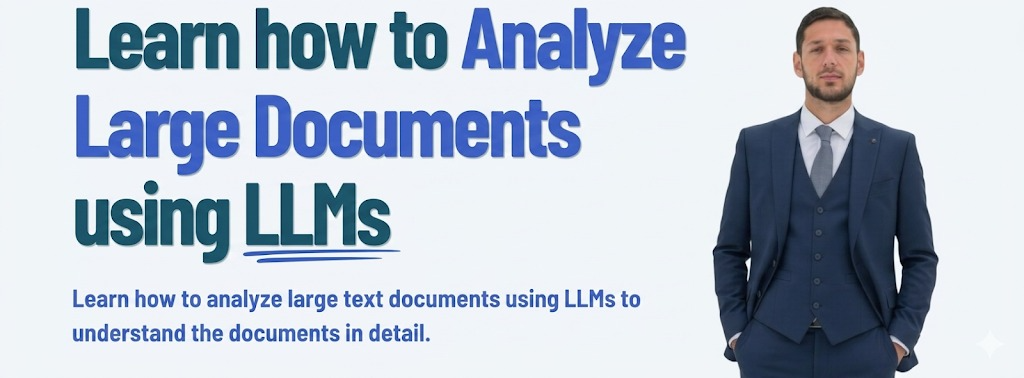

In [4]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 95.2 MB/s eta 0:00:00


#

#  **Document Analysis using LLMs with Python**
For the task of document analysis using LLMs, I’ll be using a document that contains the terms of the services offered by Google. You can download this document from here.

# **Step 1: Extract Text from the PDF**

The first step in document analysis is extracting the content from a PDF file. We can use libraries like pdfplumber to open and read the text from each page of the PDF and save it into a .txt file for further analysis. You can install pdfplumber on your Python environment using the command: pip install pdfplumber. Here’s how to extract text from the PDF:

In [5]:
import pdfplumber

pdf_path = "/content/google_terms_of_service_en_in.pdf"

output_text_file = "extracted_text.txt"

with pdfplumber.open("/content/google_terms_of_service_en_in.pdf") as pdf:
    extracted_text = ""
    for page in pdf.pages:
        extracted_text += page.extract_text()

with open(output_text_file, "w") as text_file:
    text_file.write(extracted_text)

print(f"Text extracted and saved to {output_text_file}")

Text extracted and saved to extracted_text.txt


# **Step 2: Preview the Extracted Text**

After extracting the text, it’s essential to preview the content to ensure everything is correctly captured. This allows you to check for any formatting issues or missing content:

In [6]:
# reading pdf content
with open("/content/extracted_text.txt", "r") as file:
    document_text = file.read()

# preview the document content
print(document_text[:500])  # preview the first 500 characters

GOOGLE TERMS OF SERVICE
Effective May 22, 2024 | Archived versions
What’s covered in these terms
We know it’s tempting to skip these Terms of
Service, but it’s important to establish what you
can expect from us as you use Google services,
and what we expect from you.
These Terms of Service re ect the way Google’s business works, the laws that apply to
our company, and certain things we’ve always believed to be true. As a result, these Terms
of Service help de ne Google’s relationship with you as


In [7]:
!pip uninstall -y transformers huggingface_hub tokenizers
!pip install --no-cache-dir transformers sentencepiece

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: huggingface_hub 1.11.0
Uninstalling huggingface_hub-1.11.0:
  Successfully uninstalled huggingface_hub-1.11.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 139.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 136.6 MB/s eta 0:00:00


In [8]:
!pip uninstall -y transformers huggingface_hub tokenizers accelerate

Found existing installation: transformers 5.7.0
Uninstalling transformers-5.7.0:
  Successfully uninstalled transformers-5.7.0
Found existing installation: huggingface_hub 1.13.0
Uninstalling huggingface_hub-1.13.0:
  Successfully uninstalled huggingface_hub-1.13.0
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: accelerate 1.13.0
Uninstalling accelerate-1.13.0:
  Successfully uninstalled accelerate-1.13.0


In [9]:
!pip install --no-cache-dir transformers==4.41.2 tokenizers==0.19.1 sentencepiece accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 208.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 223.3 MB/s eta 0:00:00


In [10]:
from transformers.pipelines import SUPPORTED_TASKS
print("summarization" in SUPPORTED_TASKS)

True


# **Step 3: Summarize the Document**

To get a high-level overview of the document, you can use a pre-trained summarization model like t5-small. This allows you to condense large pieces of text into shorter summaries, which helps you to grasp the most important information. Here’s how to summarize the document:

In [11]:
from transformers import pipeline

# Load text
with open("extracted_text.txt", "r", encoding="utf-8") as f:
    document_text = f.read()

# Load model
summarizer = pipeline("summarization", model="t5-small")

# Summarize
summary = summarizer(
    document_text[:1000],
    max_length=150,
    min_length=30,
    do_sample=False
)

print("Summary:", summary[0]['summary_text'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Summary: these Terms of Service reect the way Google’s business works, the laws that apply to our company, and certain things we’ve always believed to be true . these terms include: what you can expect from us, which describes how we provide and develop our services What we expect from you, which establishes certain rules for using our services Content in Google services .


In [12]:
with open("extracted_text.txt", "r", encoding="utf-8") as f:
    document_text = f.read()

In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(document_text)

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("t5-small")

tokens = tokenizer.tokenize(document_text)

Token indices sequence length is longer than the specified maximum sequence length for this model (5573 > 512). Running this sequence through the model will result in indexing errors


# **Step 4: Split the Document into Sentences and Passages**

For more detailed analysis, like question generation, it’s important to split the document into smaller chunks. This step tokenizes the document into sentences and combines them into manageable passages for subsequent steps. Here’s how to split the document into sentences and passages:

In [17]:
import nltk
nltk.download('punkt')

from nltk.tokenize import sent_tokenize

# split text into sentences
sentences = sent_tokenize(document_text)

# combine sentences into passages
passages = []
current_passage = ""

for sentence in sentences:
    if len(current_passage.split()) + len(sentence.split()) < 200:
        current_passage += " " + sentence
    else:
        passages.append(current_passage.strip())
        current_passage = sentence

if current_passage:
    passages.append(current_passage.strip())

print(passages[:2])  # preview

['GOOGLE TERMS OF SERVICE\nEffective May 22, 2024 | Archived versions\nWhat’s covered in these terms\nWe know it’s tempting to skip these Terms of\nService, but it’s important to establish what you\ncan expect from us as you use Google services,\nand what we expect from you. These Terms of Service re\x00ect the way Google’s business works, the laws that apply to\nour company, and certain things we’ve always believed to be true. As a result, these Terms\nof Service help de\x00ne Google’s relationship with you as you interact with our services. For\nexample, these terms include the following topic headings:\nWhat you can expect from us, which describes how we provide and develop our\nservices\nWhat we expect from you, which establishes certain rules for using our services\nContent in Google services, which describes the intellectual property rights to the\ncontent you \x00nd in our services — whether that content belongs to you, Google, or\nothers\nIn case of problems or disagreements, w

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Step 5: Generate Questions from the Passages Using LLMs**

The next step is to generate questions based on the document’s content. This helps in understanding key information points and can be used to check the comprehension of the document. Here’s how to generate questions from passages using LLMs:

In [18]:
# load the question generation pipeline
qg_pipeline = pipeline("text2text-generation", model="valhalla/t5-base-qg-hl")

# function to generate questions using the pipeline
def generate_questions_pipeline(passage, min_questions=3):
    input_text = f"generate questions: {passage}"
    results = qg_pipeline(input_text)
    questions = results[0]['generated_text'].split('<sep>')

    # ensure we have at least 3 questions
    questions = [q.strip() for q in questions if q.strip()]

    # if fewer than 3 questions, try to regenerate from smaller parts of the passage
    if len(questions) < min_questions:
        passage_sentences = passage.split('. ')
        for i in range(len(passage_sentences)):
            if len(questions) >= min_questions:
                break
            additional_input = ' '.join(passage_sentences[i:i+2])
            additional_results = qg_pipeline(f"generate questions: {additional_input}")
            additional_questions = additional_results[0]['generated_text'].split('<sep>')
            questions.extend([q.strip() for q in additional_questions if q.strip()])

    return questions[:min_questions]  # return only the top 3 questions

# generate questions from passages
for idx, passage in enumerate(passages):
    questions = generate_questions_pipeline(passage)
    print(f"Passage {idx+1}:\n{passage}\n")
    print("Generated Questions:")
    for q in questions:
        print(f"- {q}")
    print(f"\n{'-'*50}\n")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/15.0 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1168: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Passage 1:
GOOGLE TERMS OF SERVICE
Effective May 22, 2024 | Archived versions
What’s covered in these terms
We know it’s tempting to skip these Terms of
Service, but it’s important to establish what you
can expect from us as you use Google services,
and what we expect from you. These Terms of Service re ect the way Google’s business works, the laws that apply to
our company, and certain things we’ve always believed to be true. As a result, these Terms
of Service help de ne Google’s relationship with you as you interact with our services. For
example, these terms include the following topic headings:
What you can expect from us, which describes how we provide and develop our
services
What we expect from you, which establishes certain rules for using our services
Content in Google services, which describes the intellectual property rights to the
content you  nd in our services — whether that content belongs to you, Google, or
others
In case of problems or disagreements, which describes o

# **Step 6: Answer the Generated Questions Using a QA Model**

After generating the questions, we can use a pre-trained question-answering (QA) model to find the answers within the text. The deepset/roberta-base-squad2 model extracts answers based on the context of the passage. Here’s how to answer the generated questions:

In [19]:
# load the QA pipeline
qa_pipeline = pipeline("question-answering", model="deepset/roberta-base-squad2")

# function to track and answer only unique questions
def answer_unique_questions(passages, qa_pipeline):
    answered_questions = set()  # to store unique questions

    for idx, passage in enumerate(passages):
        questions = generate_questions_pipeline(passage)

        for question in questions:
            if question not in answered_questions:  # check if the question has already been answered
                answer = qa_pipeline({'question': question, 'context': passage})
                print(f"Q: {question}")
                print(f"A: {answer['answer']}\n")
                answered_questions.add(question)  # add the question to the set to avoid repetition
        print(f"{'='*50}\n")

answer_unique_questions(passages, qa_pipeline)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/496M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Q: What is the meaning of the Terms of Service?
A: certain things we’ve always believed to be true

Q: What are the terms of service that govern how Google operates?
A: re ect the way Google’s business works, the laws

Q: What do these Terms of Service help define?
A: Google’s relationship with you as you interact with our services


Q: What is the name of the company that provides Google services?
A: Google LLC

Q: What is the name of the company that Google LLC provides services to?
A: 
Google LLC


Q: What are the terms that govern how Google earns money?
A: how Google’s business works


Q: What are the terms of service that you can expect from Google?
A: Provide a broad range of useful services

Q: What are some of the services that Google provides that are subject to these terms?
A: apps and sites (like Search and Maps)


Q: What is one way that Google may improve its services?
A: start offering new services

Q: What does it mean to have a new feature or feature available?
A: down